In [ ]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from tqdm import tqdm

from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.networks import MLPBlock, MLPGaussianNoiseModel


loss: 22.952651977539062, reg: -2.179502487182617, rec: 25.13215446472168:  22%|██▏       | 2175/10000 [00:35<01:21, 96.14it/s]

In [2]:
# reading data
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

In [3]:
# scaling data
COFACTOR = 10_000
key_arcsin = f"X_arcsinh_cof{COFACTOR}"
adata.obsm[key_arcsin] = np.arcsinh(adata.X/COFACTOR)


In [4]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X_arcsinh_cof10000'

In [5]:
# data manager
datamanager = DataManager(
    adata,
    sample_rep=key_arcsin
)
data = datamanager.get_data()


In [6]:
# data loading
BATCH_SIZE = 128
dataloader = SequentialDataLoader(
    data,
    batch_size=BATCH_SIZE,
)


In [ ]:
# gmm decoder
class GMMDecoder(torch.nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        latent_dim,
        n_comps,
        encoder_mlp_kwargs,
        weight_mlp_kwargs,
        gmm_mlp_kwargs,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.latent_dim = latent_dim
        self.n_comps = n_comps
        self.encoder_mlp_kwargs = encoder_mlp_kwargs
        self.weight_mlp_kwargs = weight_mlp_kwargs
        self.gmm_mlp_kwargs = gmm_mlp_kwargs
        self._init_modules()

    def _init_modules(self):
        # initializing encoder
        self.encoder = MLPBlock(
            self.input_dim,
            self.latent_dim,
            **self.encoder_mlp_kwargs
        )

        # initializing weight model
        self.weight_nn = MLPBlock(
            self.latent_dim,
            self.n_comps,
            **self.weight_mlp_kwargs
        )

        # initializinng mixture models
        self.gmm_comps = torch.nn.ModuleList([
            MLPGaussianNoiseModel(
                self.latent_dim,
                self.output_dim,
                **self.gmm_mlp_kwargs
            ) for _ in range(self.n_comps)
        ])

    def forward(
        self,
        input,
    ):
        # encoding input 
        input = self.encoder(input)
        # computing weights
        weight_logits = self.weight_nn(input)
        weight_probs = torch.nn.functional.softmax(weight_logits, dim=-1)
        # computing params
        params = [
            gmm_comps(input) for gmm_comps in self.gmm_comps
        ]
        # parsing params
        mean = torch.stack([param["mean"] for param in params], dim=0)
        cov = torch.stack([param["covariance"] for param in params], dim=0) 
        return weight_probs, mean, cov 


In [58]:
# settings
INPUT_DIM = adata.X.shape[1]
INNER_LATENT_DIM = 32
LATENT_DIM = 16
N_COMPS = 1


In [59]:
# initializing nns
encoder = MLPGaussianNoiseModel(
    input_dim=INPUT_DIM,
    output_dim=LATENT_DIM,
    latent_dim=INNER_LATENT_DIM,
    use_shared_representation=True,
    encoder_mlp_kwargs={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    mean_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Identity,
    },
    cov_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Softplus,
    },
)
encoder.to("cuda")

decoder = GMMDecoder(
    input_dim=LATENT_DIM,
    output_dim=INPUT_DIM,
    latent_dim=INNER_LATENT_DIM,
    n_comps=N_COMPS,
    encoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    weight_mlp_kwargs={      
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    gmm_mlp_kwargs={
        "latent_dim": 16,
        "use_shared_representation": True,
        "encoder_mlp_kwargs": {
            "hidden_dims": (64, 64),
            "use_batchnorm": False,
            "use_dropout": False,
            "activation_class": torch.nn.SELU,
            "final_activation_class": torch.nn.Identity,
        },
        "mean_mlp_kwargs": {
            "hidden_dims": (),
            "use_batchnorm": False,
            "use_dropout": False,
            "activation_class": torch.nn.Identity,
            "final_activation_class": torch.nn.Identity,
        },
        "cov_mlp_kwargs": {
            "hidden_dims": (),
            "use_batchnorm": False,
            "use_dropout": False,
            "activation_class": torch.nn.Identity,
            "final_activation_class": torch.nn.Softplus,
        },
    }
)
decoder.to("cuda")


GMMDecoder(
  (encoder): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): SELU()
      )
      (1): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): SELU()
      )
      (2): Sequential(
        (0): Linear(in_features=64, out_features=32, bias=True)
        (1): Identity()
      )
    )
  )
  (weight_nn): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=32, out_features=64, bias=True)
        (1): SELU()
      )
      (1): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): SELU()
      )
      (2): Sequential(
        (0): Linear(in_features=64, out_features=1, bias=True)
        (1): Identity()
      )
    )
  )
  (gmm_comps): ModuleList(
    (0): MLPGaussianNoiseModel(
      (encoder): MLPBlock(
        (net): Sequential(
          (0): Sequential(
            (0): Linear(in_features=3

loss: 20.13785743713379, reg: -2.2035393714904785, rec: 19.917503356933594: 100%|██████████| 10000/10000 [05:18<00:00, 31.37it/s]
loss: 20.097820281982422, reg: -2.027324914932251, rec: 19.89508819580078: 100%|██████████| 10000/10000 [01:40<00:00, 117.68it/s] 

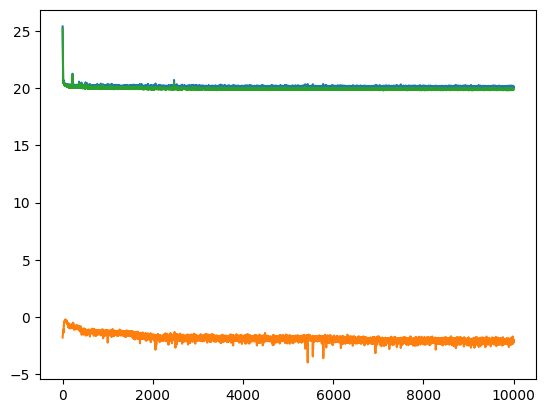

In [60]:
# defining optimizer
optimizer = torch.optim.Adam(
    itertools.chain(*[
        encoder.parameters(), 
        decoder.parameters()
    ]
    )
    , lr=1e-3
)

# iteration
n_grad_steps = 10_000
n_mc_samples = 50
iterator = range(n_grad_steps)
pbar = tqdm(iterator)

# storing progress
rec_loss_history = np.zeros((n_grad_steps, ))
reg_loss_history = np.zeros((n_grad_steps, ))
loss_history = np.zeros((n_grad_steps, ))
reg_strength = 1e-1


# iterating over gradient steps
for grad_step in iterator:
    # sampling
    states = dataloader.sample()["state_data"]

    # encoding
    latent_params = encoder(states)
    latent_mean = latent_params["mean"]
    latent_covariance = latent_params["covariance"]
    noise_samples = torch.randn_like(latent_mean)
    latent_samples = latent_mean.repeat(n_mc_samples, 1, 1) + noise_samples.repeat(n_mc_samples, 1, 1)*latent_covariance

    # decoding
    weight_probs, mean, cov = decoder(latent_samples)

    # compute regularization loss
    reg_loss = 0.5*torch.sum(
        1 + torch.log(latent_covariance**2) - latent_mean**2 - latent_covariance**2, dim=-1
    ).mean()
    # compute reconstruction loss
    dim = mean.shape[-1]
    cov = cov**2
    rec_loss = (
        (0.5 / cov) * torch.sum((states.repeat(N_COMPS, n_mc_samples, 1, 1) - mean) ** 2, axis=-1, keepdim=True)
        + 0.5 * torch.log(cov)
        + dim * 0.5 * torch.log(torch.tensor([2 * np.pi], device=mean.device))
    )[:, :, :, 0].mean(1)
    rec_loss = (weight_probs @ rec_loss).mean()
    loss = rec_loss - reg_strength*reg_loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # logging
    pbar.set_description(f"loss: {loss.item()}, reg: {reg_loss.item()}, rec: {rec_loss.item()}")
    pbar.update()
    loss_history[grad_step] = loss.item()
    reg_loss_history[grad_step] = reg_loss.item()
    rec_loss_history[grad_step] = rec_loss.item()

# plotting
plt.plot(loss_history)
plt.plot(reg_loss_history)
plt.plot(rec_loss_history)


In [ ]:
z = torch.randn((64, LATENT_DIM)).to("cuda")
weight_probs, mean, cov = decoder(z)
weight_probs, mean, cov 


(tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.]], device='cuda:0', grad_fn=<SoftmaxBackwa

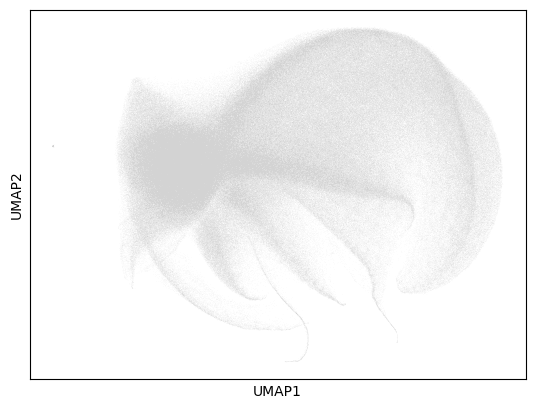

In [ ]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata)


In [ ]:
weight_probs.shape


torch.Size([64, 1])